# Language analysis notebook

Celem tego notatnika jest empiryczne zbadanie skuteczności funkcji
`language_words_with_frequency`, która mierzy dopasowanie słów z analizowanego
tekstu do listy najczęściej używanych słów w danym języku.



## Description and experimental setup

W tym notatniku badam skuteczność metody `language_words_with_frequency`
dla trzech języków:
- język wiki: **EN**
- dwa dodatkowe języki: **IT**, **ES**

Analiza wykonywana jest dla wartości:
k ∈ {3, 10, 100, 1000}

### Dane językowe
Dla każdego z trzech języków pobieram listę co najmniej 1000 najczęściej
używanych słów wraz z ich częstościami (z wykorzystaniem biblioteki `wordfreq`).

### Teksty testowe
Łącznie analizuję pięć tekstów:
1. długi artykuł z wiki w języku EN (≥ 5000 słów),
2. artykuł z wiki w języku EN dobrany tak, aby wynik metody był możliwie niski
   względem innych języków (≥ 20 słów),
3. długi tekst spoza wiki w języku IT: *Umberto Eco – "Il nome della rosa"*,
4. długi tekst spoza wiki w języku EN: *Charles Dickens – "Oliver Twist"*,
5. długi tekst spoza wiki w języku ES: *Miguel de Unamuno – "Niebla"*.

Dla każdego tekstu tworzony jest słownik `word-counts`, a następnie obliczana
jest wartość funkcji `language_words_with_frequency` dla wszystkich języków
i wartości k.


## Imports and configs

Tutaj definiuję ścieżki do zapisu countsów a także tryb zliczania pewności przez funkcję. 

In [36]:
from pathlib import Path

from wikiscraper.analysis.words import WordCounter
from wikiscraper.scraper.client import WikiClient
from wikiscraper.scraper.parser import ArticleParser

### path to counts
save_path = Path("store_counts/")

### config
mode = "coverage"

## Defining different scoring options

Metoda `"coverage"` mierzy, jaki ułamek słów tekstu należy do listy najczęstszych k słów danego języka.
Metoda `"weighted_coverage"` dodatkowo uwzględnia częstości słów w języku, premiując słowa bardziej typowe.
Metoda `"rank"` opiera się na pozycji słów w rankingu częstotliwości i premiuje użycie najbardziej funkcjonalnych słów języka, niezależnie od ich bezwzględnych częstości.

In [37]:
def lang_confidence_score(word_counts, language_words_with_frequency, mode="coverage"):
    if mode == "coverage":
        top_k = set(language_words_with_frequency.keys())
        total = sum(word_counts.values())
        covered = sum(count for word, count in word_counts.items() if word in top_k)
        return covered / total
    elif mode == "weighted_coverage":
        top_k = language_words_with_frequency
        total = sum(word_counts.values())

        score = 0
        for word, count in word_counts.items():
            if word in top_k:
                score += count * top_k[word]

        return score / total
    elif mode == "rank":
        rank = {w: i + 1 for i, w in enumerate(language_words_with_frequency.keys())}
        total = sum(word_counts.values())
        score = 0

        for word, count in word_counts.items():
            if word in rank:
                score += count * (1 / rank[word])

        return score / total

## Explorative loop to find worst wiki article

### Selection of a "hard" wiki article

Aby znaleźć artykuł z wiki, dla którego wynik metody
`language_words_with_frequency` dla języka wiki (EN) jest możliwie niski,
przeglądam kolejne artykuły z wiki i obliczam wynik metody.

Proces ten ograniczam do maksymalnie 50 artykułów. Następnie wybieram artykuł,
dla którego wynik dla języka EN jest relatywnie niski w porównaniu do pozostałych
języków. Jeśli nie udałoby się znaleźć jednoznacznie trudnego przypadku,
wybieram najgorszy z przetestowanych artykułów.

In [38]:
### Crawler to get texts
from wikiscraper.analysis.words import RelativeFrequencyAnalyzer

phrase = "Team_Rocket"  ### I will look at kids of Team Rocket - could be any other starting point
explorative_texts = {}
client = WikiClient()
html = client.fetch_html(phrase)
parser = ArticleParser(html)
links = parser.extract_links()

for link in links[:51]:
    html = client.fetch_html(link)
    parser = ArticleParser(html)
    text = parser.extract_article_text()
    save_phrase = save_path / f"{link}.json"
    counter = WordCounter(counts_path=save_phrase)
    tokens = counter.tokenize(text)
    if Path(save_phrase).exists():
        counter.reset_counts()
    current_dict = counter.run(text)
    explorative_texts[link] = current_dict

In [39]:
### Find those with the lowest english to it and es difference
texts = explorative_texts.keys()
languages = ["en", "es", "it"]
scores = {}
for text in texts:
    scores[text] = {}
    for ln in languages:
        freq_analyzer = RelativeFrequencyAnalyzer(
            top_k=1000,
            mode="language",
            lang=ln,
            lang_top_k=1000,
            counts=explorative_texts[text],
        )
        article_norm, lang_norm, selected_words = freq_analyzer.return_norms()
        scores[text][ln] = lang_confidence_score(
            explorative_texts[text], lang_norm, mode=mode
        )

In [40]:
### pick text with lowest results for other languages
sum_dict = {
    text: (scores[text]["en"] - scores[text]["es"])
    + (scores[text]["en"]
    - (scores[text]["it"]))
    for text in scores.keys()
}
sorted(sum_dict.items(), key=lambda x: x[1])
### So the choice is "Five_Island"
chosen = sorted(sum_dict.items(), key=lambda x: x[1])[0][0]
chosen

'Proton'

## Loading data and processing to a dictionary

In [41]:
texts_dicts = {}

texts = ["english.txt", "italian.txt", "spanish.txt"]  ### teksty z literatury
phrases = [
    chosen,
    "Team Rocket",  ### dluzszy artykul
]

for phrase in phrases:
    client = WikiClient()
    html = client.fetch_html(phrase)
    parser = ArticleParser(html)
    text = parser.extract_article_text()
    rocket_text = text
    save_phrase = save_path / f"{phrase}.json"
    counter = WordCounter(counts_path=save_phrase)
    tokens = counter.tokenize(text)
    if Path(save_phrase).exists():
        counter.reset_counts()
    current_dict = counter.run(text)
    texts_dicts[phrase] = current_dict
    # links = parser.extract_links(prefix="/wiki/")
    # print(len(tokens))

for txt in texts:
    save_text = save_path / f"{txt}"
    with open(save_text, "r") as f:
        text = Path(save_text).read_text(encoding="utf-8")
        counter = WordCounter(counts_path=save_path / f"{txt[:-4]}.json")
        tokens = counter.tokenize(text)
        if Path(save_text).exists():
            counter.reset_counts()
        current_dict = counter.run(text)
        texts_dicts[txt[:-4]] = current_dict
        # print(len(tokens))

In [42]:
for name, wc in texts_dicts.items():
    print(name, "unique:", len(wc), "total:", sum(wc.values()))

Proton unique: 319 total: 728
Team Rocket unique: 1517 total: 6271
english unique: 1402 total: 5027
italian unique: 1974 total: 5307
spanish unique: 1705 total: 6094


### Final loop with selected articles to calculate scores

Wyniki obliczeń zapisywane są w tabeli w formacie „long”, gdzie każda obserwacja
odpowiada trójce (tekst, język, wartość k) i zawiera wynik funkcji
`language_words_with_frequency`. Taki format ułatwia porównania oraz
wizualizację wyników.


In [43]:
from wikiscraper.analysis.words import RelativeFrequencyAnalyzer

languages = ["en", "it", "es"]
freqs = {}
scores = {}
for k in [3, 10, 100, 500, 1000]:
    scores[str(k)] = {}
    for name, txt in texts_dicts.items():
        scores[str(k)][name] = {}
        for ln in languages:
            freq_analyzer = RelativeFrequencyAnalyzer(
                top_k=1000,
                mode="language",
                lang=ln,
                lang_top_k=k,
                counts=texts_dicts[name],
            )
            article_norm, lang_norm, selected_words = freq_analyzer.return_norms()
            scores[str(k)][name][ln] = lang_confidence_score(
                texts_dicts[name], lang_norm, mode=mode
            )

In [44]:
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import pandas as pd


def scores_dict_to_df(
    scores: dict,
    ks: Optional[Iterable[int]] = None,
    texts: Optional[Iterable[str]] = None,
    languages: Optional[Iterable[str]] = None,
) -> pd.DataFrame:

    # infer ks/texts/languages if not provided
    all_ks = sorted(scores.keys())
    if ks is None:
        ks = all_ks
    else:
        ks = sorted(ks)

    sample_k = next(iter(scores))
    all_texts = sorted(scores[sample_k].keys())
    if texts is None:
        texts = all_texts
    else:
        texts = list(texts)

    sample_text = next(iter(scores[sample_k]))
    all_langs = sorted(scores[sample_k][sample_text].keys())
    if languages is None:
        languages = all_langs
    else:
        languages = list(languages)

    rows = []
    for k in ks:
        for text in texts:
            for lang in languages:
                val = scores.get(k, {}).get(text, {}).get(lang, None)
                rows.append({"k": k, "text": text, "language": lang, "score": val})

    df = pd.DataFrame(rows)
    df["k"] = df["k"].astype(int)
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    return df


def plot_df_per_text(
    df: pd.DataFrame,
    ks: Optional[Iterable[int]] = None,
    texts: Optional[Iterable[str]] = None,
    languages: Optional[Iterable[str]] = None,
    title_prefix: str = "Language confidence",
    xscale_log: bool = True,
) -> None:
    if ks is not None:
        df = df[df["k"].isin(list(ks))]
    if texts is not None:
        df = df[df["text"].isin(list(texts))]
    if languages is not None:
        df = df[df["language"].isin(list(languages))]

    for text, sub in df.groupby("text", sort=True):
        plt.figure(figsize=(9, 4.8))
        for lang, sub2 in sub.groupby("language", sort=True):
            sub2 = sub2.sort_values("k")
            plt.plot(sub2["k"], sub2["score"], marker="o", label=lang)

        if xscale_log:
            plt.xscale("log")

        plt.title(f"{title_prefix} — text: {text}")
        plt.xlabel("k (top-k words)")
        plt.ylabel("score")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
        plt.legend()
        plt.show()


def plot_df_per_language(
    df: pd.DataFrame,
    ks: Optional[Iterable[int]] = None,
    texts: Optional[Iterable[str]] = None,
    languages: Optional[Iterable[str]] = None,
    title_prefix: str = "Language confidence",
    xscale_log: bool = True,
) -> None:

    if ks is not None:
        df = df[df["k"].isin(list(ks))]
    if texts is not None:
        df = df[df["text"].isin(list(texts))]
    if languages is not None:
        df = df[df["language"].isin(list(languages))]

    for lang, sub in df.groupby("language", sort=True):
        plt.figure(figsize=(9, 4.8))
        for text, sub2 in sub.groupby("text", sort=True):
            sub2 = sub2.sort_values("k")
            plt.plot(sub2["k"], sub2["score"], marker="o", label=text)

        if xscale_log:
            plt.xscale("log")

        plt.title(f"{title_prefix} — language: {lang}")
        plt.xlabel("k (top-k words)")
        plt.ylabel("score")
        plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.6)
        plt.legend()
        plt.show()

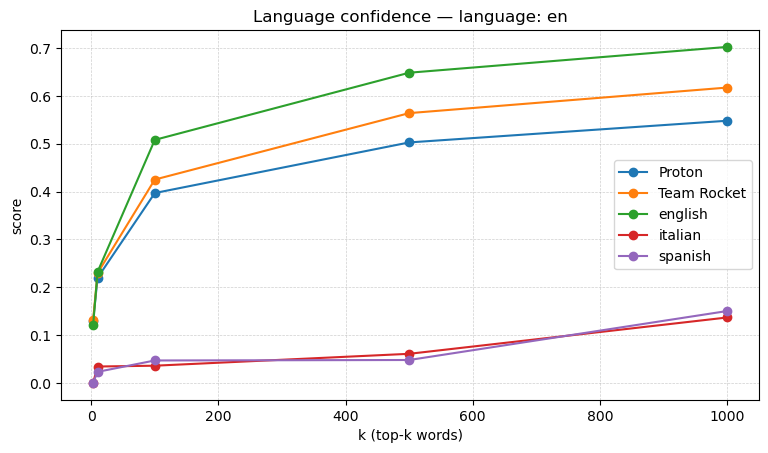

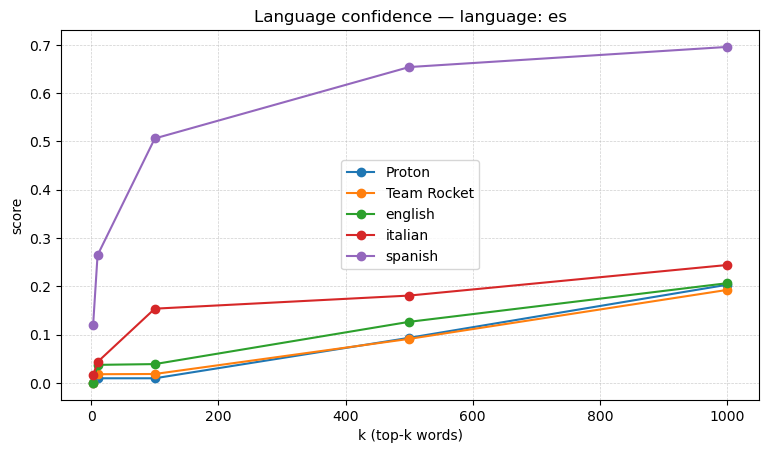

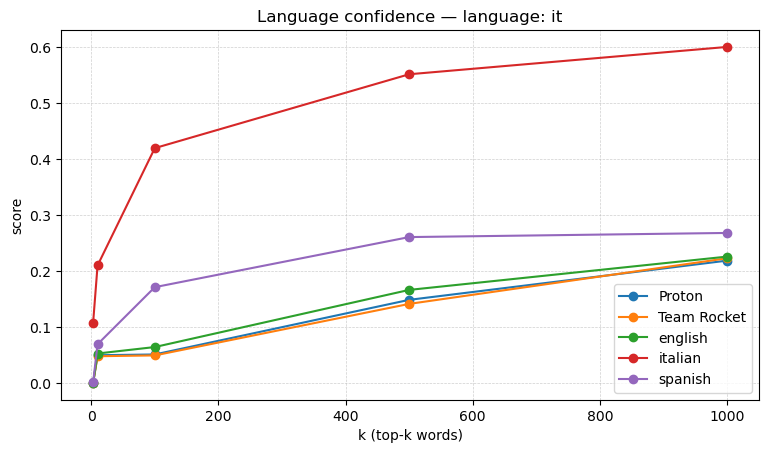

In [45]:
df = scores_dict_to_df(scores)
# plot_df_per_text(df, ks=[3, 10, 100,500, 1000], xscale_log=False)
plot_df_per_language(df, ks=[3, 10, 100, 500, 1000], xscale_log=False)

## Results and interpretation - for method "rank"

### Effect of parameter k
Dla bardzo małych wartości k (np. 3) wyniki są bardziej zmienne i zależne od przypadku.
Dla k = 100 i k = 1000 metoda osiąga stabilne wartości i najlepszą separację języków.
Zwiększanie k powyżej 100 nie prowadzi do istotnych zmian wyniku, co sugeruje, że większość informacji językowej zawarta jest już w pierwszych kilkuset najczęstszych słowach.

### Language discrimination
Dla długich tekstów spoza wiki metoda zazwyczaj przypisuje najwyższy wynik
poprawnemu językowi, szczególnie dla k = 100 oraz k = 1000. Dla niskich k separacja 
wciąż wygląda nieźle w szczególności z użyciem trybu "rank".

---

## Answers to the questions from the assignment

### Did the choice of languages matter?
Tak. Języki romańskie (włoski i hiszpański) mają bardziej zbliżone wyniki między sobą niż względem angielskiego, jednak metoda rank nadal pozwala je skutecznie rozróżnić. Separacja jest wyraźniejsza dla większych k.

### Is inflection visible in the scores?
Tak. W językach romańskich fleksja powoduje, że część form nie znajduje się w najwyższych rangach listy częstych słów, co obniża wynik dla małych k. Efekt ten jest jednak w dużej mierze niwelowany przy k ≥ 100.

### Was it difficult to find a wiki article with a low score?
Znalezienie artykułu z wiki o niskim wyniku dla języka EN było umiarkowanie
trudne. Większość artykułów wiki zawiera wiele typowych słów funkcyjnych,
co sprzyja wysokiemu wynikowi dla poprawnego języka.


### BONUS: what changes with "coverage" method?

W przeciwieństwie do metody rank, metoda coverage silnie zależy od wartości parametru k. Wraz ze wzrostem liczby uwzględnianych najczęstszych słów rośnie odsetek słów tekstu należących do top-k danego języka, co prowadzi do niemal monotonicznego wzrostu wyniku dla wszystkich języków.
Poprawny język nadal osiąga najwyższy wynik, jednak separacja między językami jest mniejsza niż w przypadku metody rank, szczególnie dla dużych wartości k, gdzie wiele języków zaczyna pokrywać podobną część słownika funkcjonalnego.